In [12]:
import numpy as np
import pandas as pd
import pickle
import joblib
import json
from google.colab import drive
drive.mount('/content/drive')


BASE_FILE_PATH = '/content/drive/MyDrive/dblp-ref/'
CLUSTER_PATH = BASE_FILE_PATH + "Clustering/"
PARQUET_FILE = BASE_FILE_PATH + 'papers.parquet'
TFIDF_MATRIX = BASE_FILE_PATH + 'tfidf_matrix.pkl'
TFIDF_VECTORIZER = BASE_FILE_PATH + 'tfidf_vectorizer.pkl'
UMAP_LABELED = CLUSTER_PATH + 'df_umap_labeled.parquet'

X = pd.read_parquet(PARQUET_FILE)
df_labels = pd.read_parquet(UMAP_LABELED)
with open(CLUSTER_PATH + 'topic_mapping.json', 'r') as f:
    topic_labels = json.load(f)

display(X.head())
display(df_labels.head())
display(topic_labels)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,abstract,authors,n_citation,references,title,venue,year,id
0,The purpose of this study is to develop a lear...,"[Makoto Satoh, Ryo Muramatsu, Mizue Kayama, Ka...",0,"[51c7e02e-f5ed-431a-8cf5-f761f266d4be, 69b625b...",Preliminary Design of a Network Protocol Learn...,international conference on human-computer int...,2013,00127ee2-cb05-48ce-bc49-9de556b93346
1,This paper describes the design and implementa...,"[Gareth Beale, Graeme Earl]",50,"[10482dd3-4642-4193-842f-85f3b70fcf65, 3133714...",A methodology for the physically accurate visu...,visual analytics science and technology,2011,001c58d3-26ad-46b3-ab3a-c1e557d16821
2,This article applied GARCH model instead AR or...,"[Altaf Hossain, Faisal Zaman, Mohammed Nasser,...",50,"[2d84c0f2-e656-4ce7-b018-90eda1c132fe, a083a1b...","Comparison of GARCH, Neural Network and Suppor...",pattern recognition and machine intelligence,2009,001c8744-73c4-4b04-9364-22d31a10dbf1
3,None,"[Jea-Bum Park, Byungmok Kim, Jian Shen, Sun-Yo...",0,"[8c78e4b0-632b-4293-b491-85b1976675e6, 9cdc54f...",Development of Remote Monitoring and Control D...,,2011,00338203-9eb3-40c5-9f31-cbac73a519ec
4,None,"[Giovanna Guerrini, Isabella Merlo]",2,None,Reasonig about Set-Oriented Methods in Object ...,,1998,0040b022-1472-4f70-a753-74832df65266


,umap-x,umap-y,dominant_topic,ssl_label,predicted_topic
0,-0.332385,0.674451,5,-1,5
1,1.030782,8.702583,6,-1,6
2,4.556381,9.291112,19,-1,8
3,-4.651358,5.321209,13,-1,13
4,-0.785592,11.319127,23,-1,23


{'0': 'Numerical Methods',
 '1': 'Networking',
 '2': 'Information Systems, Business',
 '3': 'Digital Image Processing',
 '4': 'Algorithms & Data Structures',
 '5': 'Machine Learning',
 '6': 'Data Science',
 '7': 'Search Engine, Semantics',
 '8': 'Statistical Modeling',
 '9': 'Signal Processing',
 '10': 'Fuzzy logic',
 '11': 'Cloud Infrastructure',
 '12': 'Speech/Face Recognition',
 '13': 'Control Systems',
 '14': 'Power',
 '15': 'Software Engineering Principles',
 '16': 'Mobile',
 '17': 'Agentic AI',
 '18': 'Performance',
 '19': 'Scheduling',
 '20': 'Graphing',
 '21': 'Video Processing',
 '22': 'CyberSec',
 '23': 'Classification',
 '24': 'Robotics'}

In [13]:
df_final = pd.concat([X, df_labels], axis=1)
display(df_final.head())

,abstract,authors,n_citation,references,title,venue,year,id,umap-x,umap-y,dominant_topic,ssl_label,predicted_topic
0,The purpose of this study is to develop a lear...,"[Makoto Satoh, Ryo Muramatsu, Mizue Kayama, Ka...",0,"[51c7e02e-f5ed-431a-8cf5-f761f266d4be, 69b625b...",Preliminary Design of a Network Protocol Learn...,international conference on human-computer int...,2013,00127ee2-cb05-48ce-bc49-9de556b93346,-0.332385,0.674451,5,-1,5
1,This paper describes the design and implementa...,"[Gareth Beale, Graeme Earl]",50,"[10482dd3-4642-4193-842f-85f3b70fcf65, 3133714...",A methodology for the physically accurate visu...,visual analytics science and technology,2011,001c58d3-26ad-46b3-ab3a-c1e557d16821,1.030782,8.702583,6,-1,6
2,This article applied GARCH model instead AR or...,"[Altaf Hossain, Faisal Zaman, Mohammed Nasser,...",50,"[2d84c0f2-e656-4ce7-b018-90eda1c132fe, a083a1b...","Comparison of GARCH, Neural Network and Suppor...",pattern recognition and machine intelligence,2009,001c8744-73c4-4b04-9364-22d31a10dbf1,4.556381,9.291112,19,-1,8
3,None,"[Jea-Bum Park, Byungmok Kim, Jian Shen, Sun-Yo...",0,"[8c78e4b0-632b-4293-b491-85b1976675e6, 9cdc54f...",Development of Remote Monitoring and Control D...,,2011,00338203-9eb3-40c5-9f31-cbac73a519ec,-4.651358,5.321209,13,-1,13
4,None,"[Giovanna Guerrini, Isabella Merlo]",2,None,Reasonig about Set-Oriented Methods in Object ...,,1998,0040b022-1472-4f70-a753-74832df65266,-0.785592,11.319127,23,-1,23


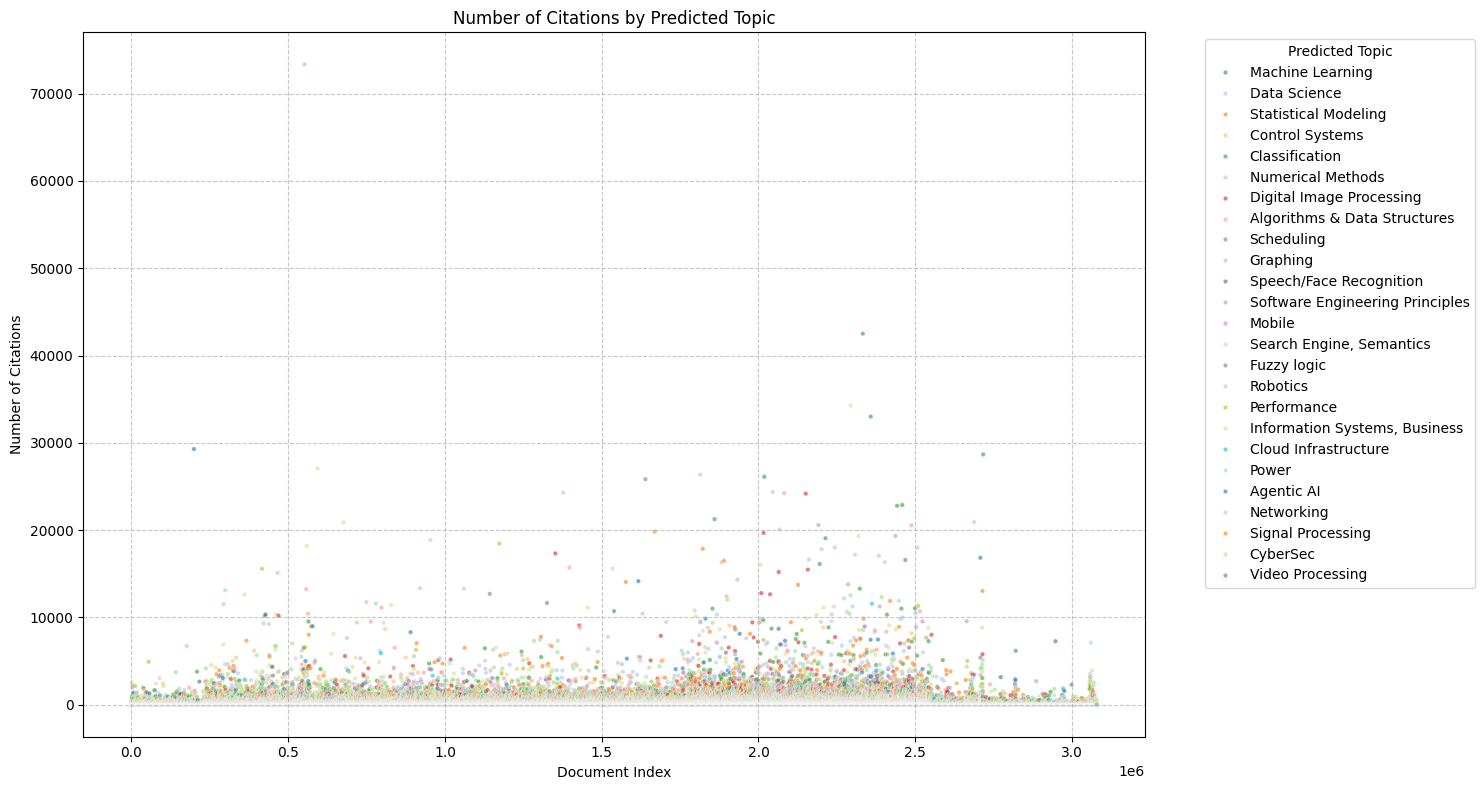

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

df_final['predicted_topic_name'] = df_final['predicted_topic'].astype(str).map(topic_labels)

fig = plt.figure(figsize=(15, 8))
sns.scatterplot(data=df_final, x=df_final.index, y='n_citation', hue='predicted_topic_name', palette='tab20', s=10, alpha=0.6)
plt.title('Number of Citations by Predicted Topic')
plt.xlabel('Document Index')
plt.ylabel('Number of Citations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Predicted Topic')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2599/998831481.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=citations_per_topic, x='predicted_topic_name', y='n_citation', palette='viridis')


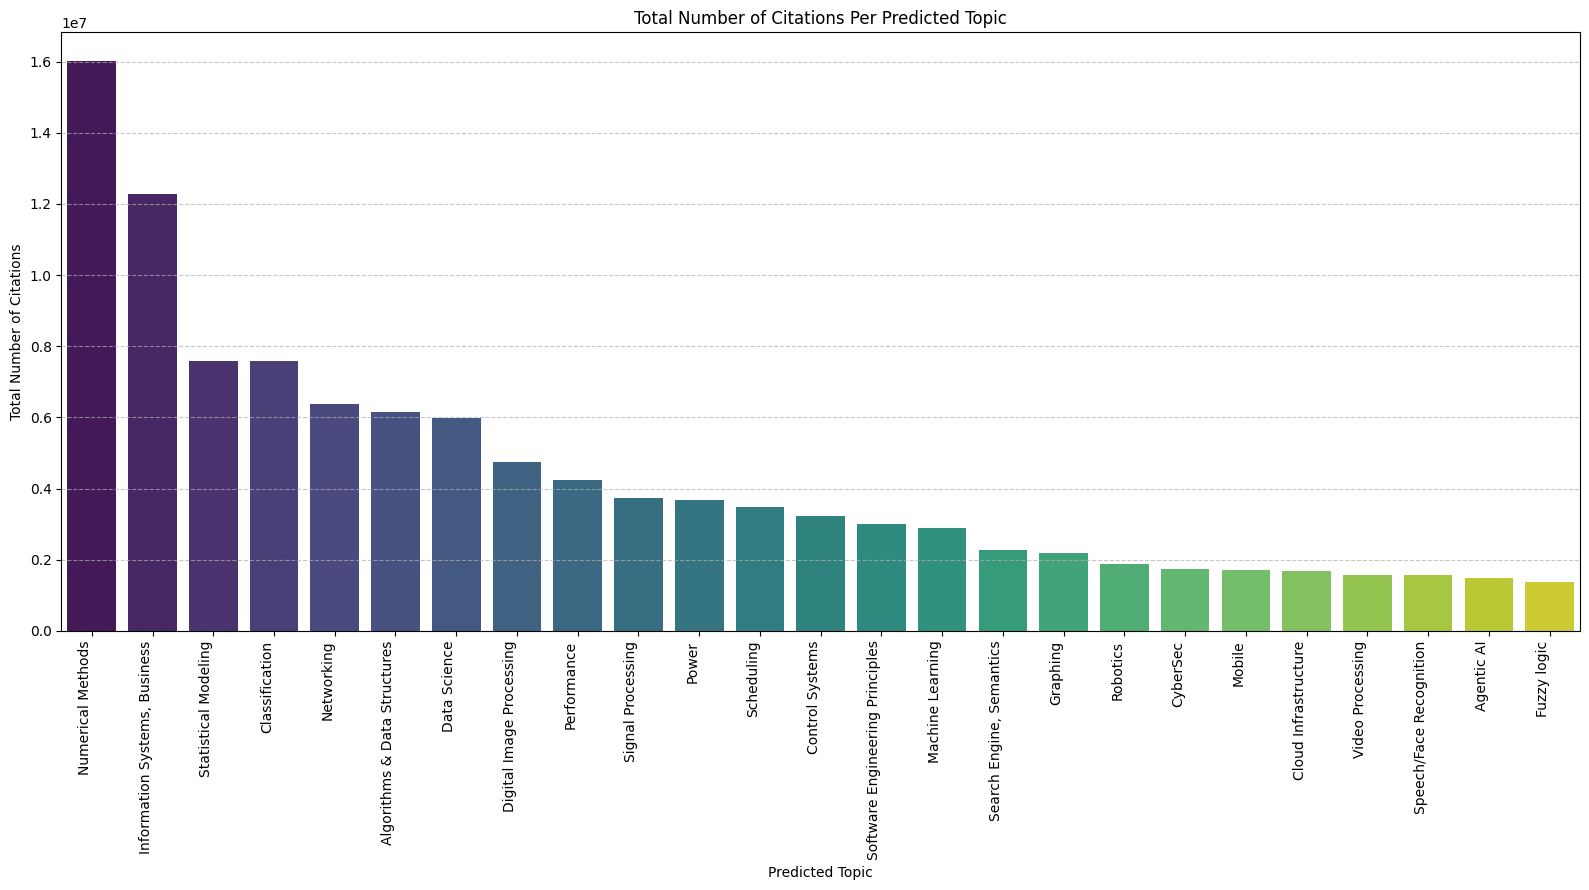

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total citations per topic
citations_per_topic = df_final.groupby('predicted_topic_name')['n_citation'].sum().reset_index()

# Sort for better visualization if desired (e.g., by citation count)
citations_per_topic = citations_per_topic.sort_values(by='n_citation', ascending=False)

# Create the bar plot
fig = plt.figure(figsize=(16, 9))
sns.barplot(data=citations_per_topic, x='predicted_topic_name', y='n_citation', palette='viridis')
plt.title('Total Number of Citations Per Predicted Topic')
plt.xlabel('Predicted Topic')
plt.ylabel('Total Number of Citations')
plt.xticks(rotation=90, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

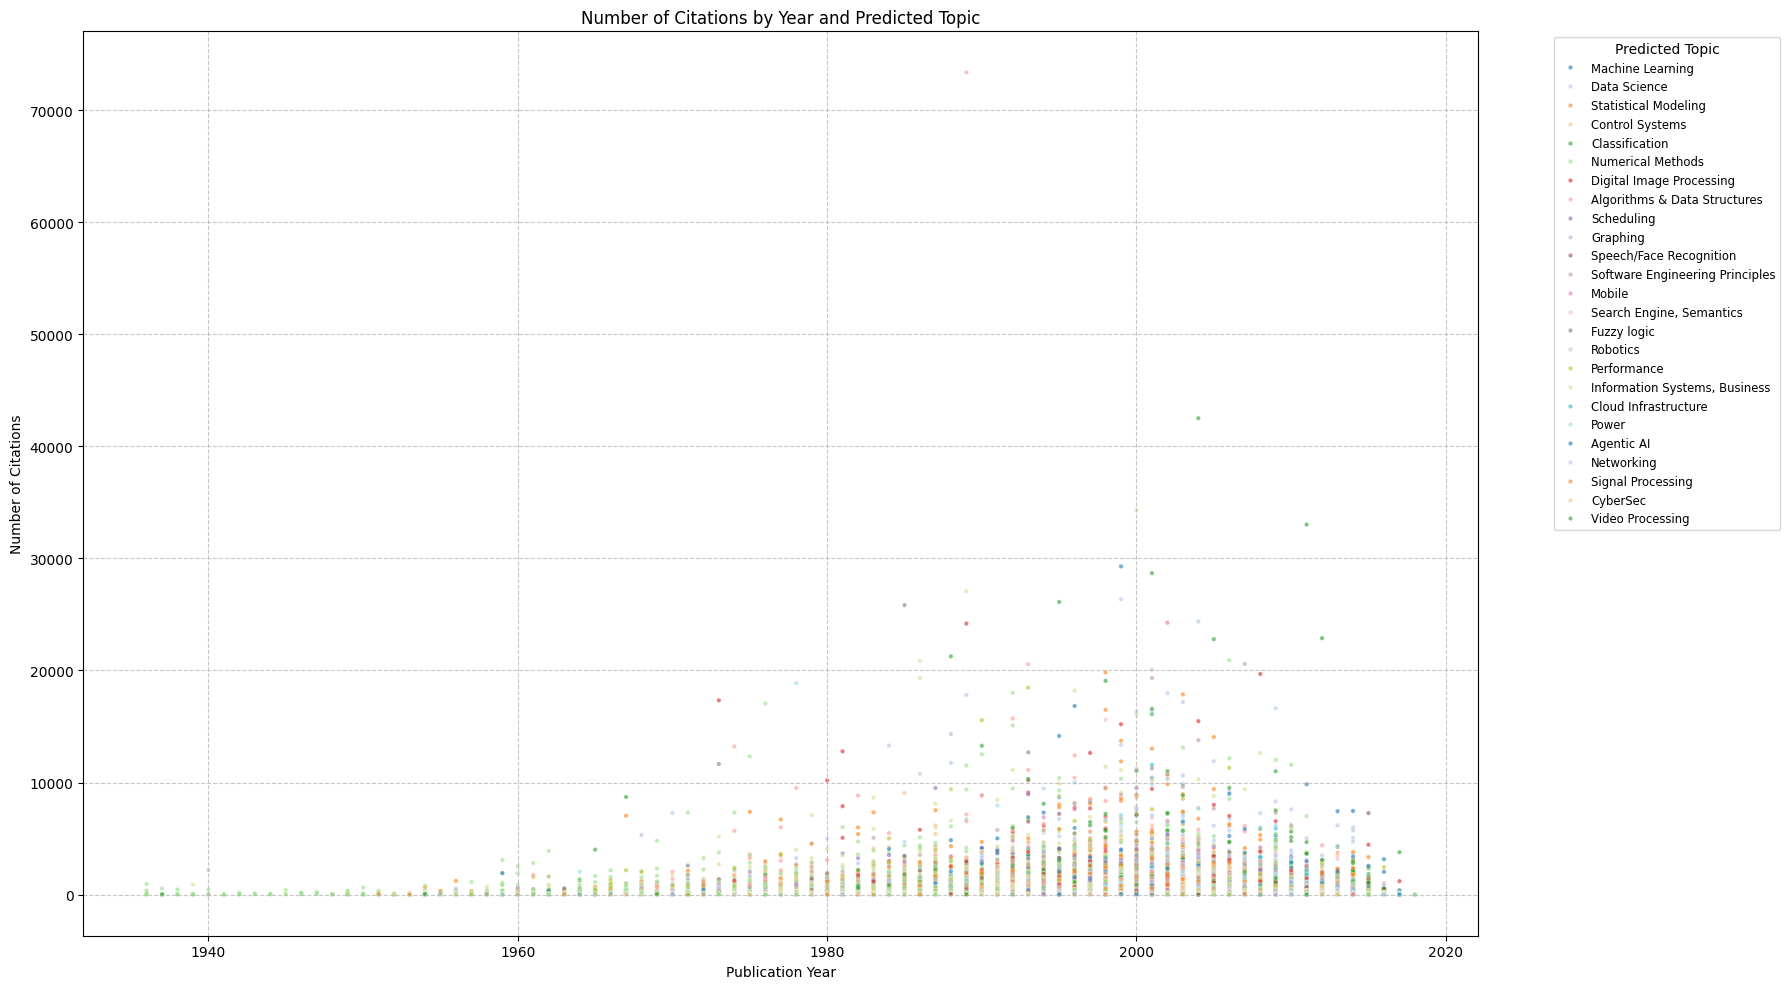

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(18, 10))
sns.scatterplot(data=df_final, x='year', y='n_citation', hue='predicted_topic_name', palette='tab20', s=10, alpha=0.6)
plt.title('Number of Citations by Year and Predicted Topic')
plt.xlabel('Publication Year')
plt.ylabel('Number of Citations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Predicted Topic', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
Q1 = df_final['n_citation'].quantile(0.25)
Q3 = df_final['n_citation'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df_final[(df_final['n_citation'] >= lower_bound) & (df_final['n_citation'] <= upper_bound)]

print(f"Original number of data points: {len(df_final)}")
print(f"Number of data points after outlier removal: {len(df_filtered)}")
print(f"Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")


Original number of data points: 3079007
Number of data points after outlier removal: 2973153
Outlier bounds: [-72.50, 123.50]


### Citation Trends Per Predicted Topic Over Time
To understand how the citations for each predicted topic have evolved over the years, we will aggregate the `n_citation` values by `year` and `predicted_topic_name`. A line plot will then be used to visualize these trends, with each line representing a different topic.

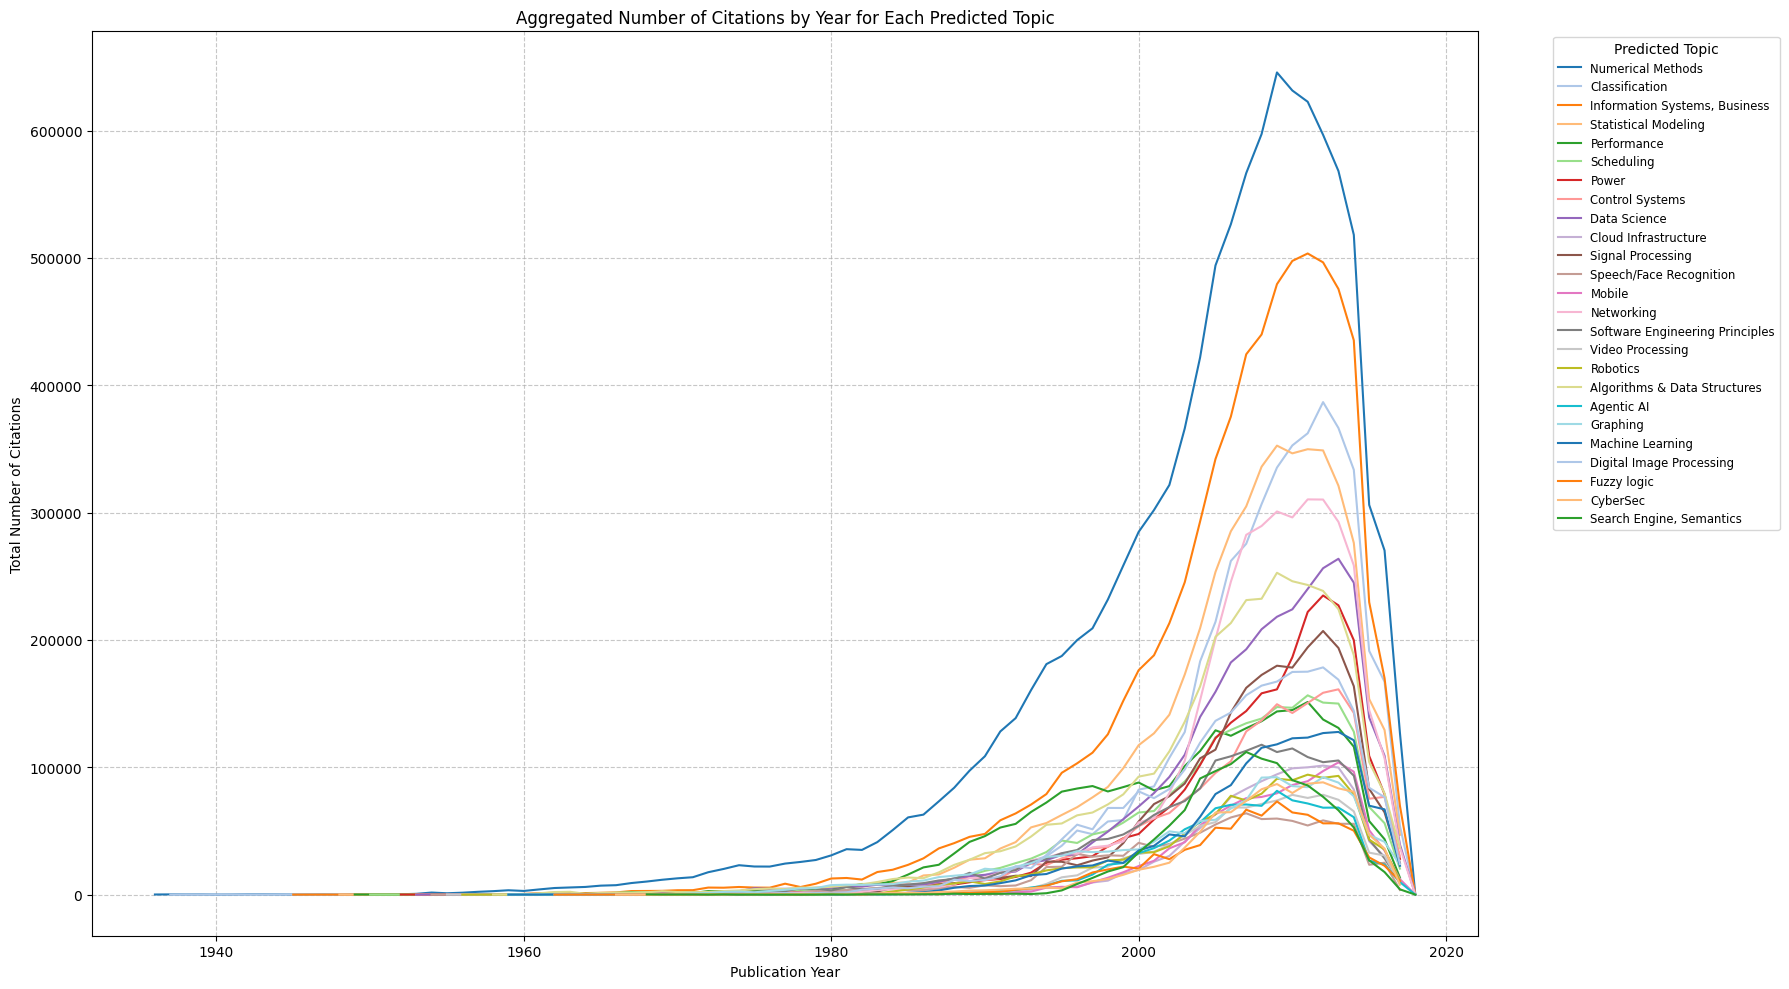

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate citation numbers per year for each predicted topic
citations_by_year_topic = df_filtered.groupby(['year', 'predicted_topic_name'])['n_citation'].sum().reset_index()

# Filter out years that might be anomalous or have very few data points, if necessary.
# For example, if 'year' is not clean or has values like 0 or future dates.
# Let's assume 'year' is clean for now. If not, might need an additional filtering step.

fig = plt.figure(figsize=(18, 10))
sns.lineplot(data=citations_by_year_topic, x='year', y='n_citation', hue='predicted_topic_name', palette='tab20')
plt.title('Aggregated Number of Citations by Year for Each Predicted Topic')
plt.xlabel('Publication Year')
plt.ylabel('Total Number of Citations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Predicted Topic', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
numerical_methods_docs = df_final[df_final['predicted_topic_name'] == 'Numerical Methods']

# Display title and abstract for a couple of examples
print("\n--- Example 1 (Numerical Methods) ---")
example1 = numerical_methods_docs[['title', 'abstract']].iloc[0]
print(f"Title: {example1['title']}")
print(f"Abstract: {example1['abstract']}\n")

print("\n--- Example 2 (Numerical Methods) ---")
example2 = numerical_methods_docs[['title', 'abstract']].iloc[1]
print(f"Title: {example2['title']}")
print(f"Abstract: {example2['abstract']}\n")

print("\n--- Example 3 (Numerical Methods) ---")
example3 = numerical_methods_docs[['title', 'abstract']].iloc[2] # Changed index to get a different example
print(f"Title: {example3['title']}")
print(f"Abstract: {example3['abstract']}\n")


--- Example 1 (Numerical Methods) ---
Title: COMPARING GNG3D AND QUADRIC ERROR METRICS METHODS TO SIMPLIFY 3D MESHES
Abstract: None


--- Example 2 (Numerical Methods) ---
Title: Multisymplectic Spectral Methods for the Gross-Pitaevskii Equation
Abstract: Recently, Bridges and Reich introduced the concept of multisymplectic spectral discretizations for Hamiltonian wave equations with periodic boundary conditions [5]. In this paper, we show that the ID nonlinear Schrodinger equation and the 2D Gross-Pitaevskii equation are multi-symplectic and derive multi-symplectic spectral discretizations of these systems. The effectiveness of the discretizations is numerically tested using initial data for multi-phase solutions.


--- Example 3 (Numerical Methods) ---
Title: Relational Abstract Interpretation of Higher Order Functional Programs (extended abstract)
Abstract: Most applications of the abstract interpretation framework[2] have been foranalyzing functional programs use functions on abst

In [20]:
information_systems_docs = df_final[df_final['predicted_topic_name'] == 'Information Systems, Business']

print("\n--- Example 1 (Information Systems, Business) ---")
example1_is = information_systems_docs[['title', 'abstract']].iloc[0]
print(f"Title: {example1_is['title']}")
print(f"Abstract: {example1_is['abstract']}\n")

print("\n--- Example 2 (Information Systems, Business) ---")
example2_is = information_systems_docs[['title', 'abstract']].iloc[1]
print(f"Title: {example2_is['title']}")
print(f"Abstract: {example2_is['abstract']}\n")

print("\n--- Example 3 (Information Systems, Business) ---")
example3_is = information_systems_docs[['title', 'abstract']].iloc[2]
print(f"Title: {example3_is['title']}")
print(f"Abstract: {example3_is['abstract']}\n")


--- Example 1 (Information Systems, Business) ---
Title: Heuristic Principles Supporting Making Time Critical Decisions in Knowledge-Based Systems.
Abstract: None


--- Example 2 (Information Systems, Business) ---
Title: Online discussion boards - friend or foe?
Abstract: None


--- Example 3 (Information Systems, Business) ---
Title: Qualitative Spatial and Temporal Reasoning in Cardiac Electrophysiology
Abstract: None



In [21]:
top_topics_per_year = citations_by_year_topic.groupby('year').apply(lambda x: x.nlargest(5, 'n_citation')).reset_index(drop=True)

display(top_topics_per_year)

/tmp/ipykernel_2599/1125713751.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_topics_per_year = citations_by_year_topic.groupby('year').apply(lambda x: x.nlargest(5, 'n_citation')).reset_index(drop=True)


,year,predicted_topic_name,n_citation
0,1936,Numerical Methods,94
1,1937,Numerical Methods,172
2,1937,Classification,18
3,1938,Numerical Methods,104
4,1939,Numerical Methods,130
...,...,...,...
354,2018,Data Science,50
355,2018,"Information Systems, Business",50
356,2018,Agentic AI,0
357,2018,Classification,0


/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:413: UserWarning: `bins` cannot be 'auto' when using weights. Setting `bins=10`, but you will likely want to adjust.
  warnings.warn(msg, UserWarning)


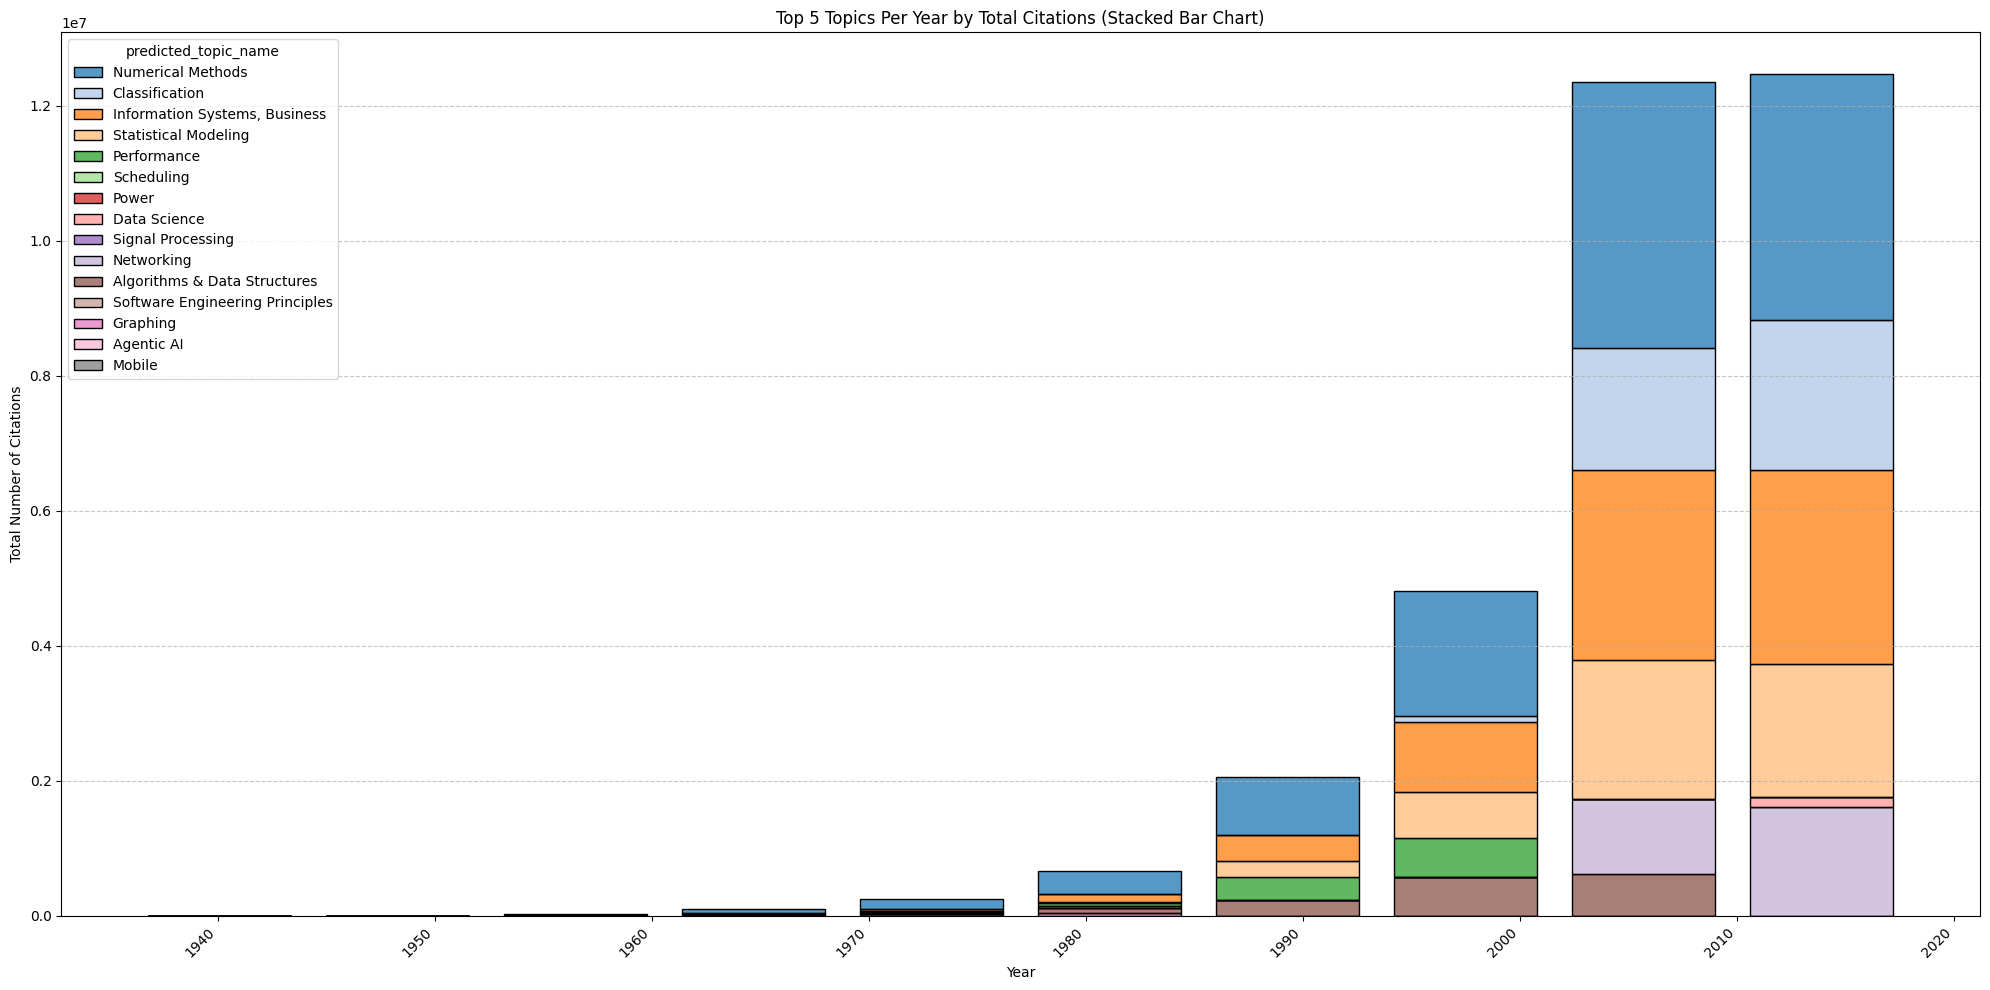

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(20, 10))
sns.histplot(
    data=top_topics_per_year,
    x='year',
    weights='n_citation',
    hue='predicted_topic_name',
    multiple='stack',
    palette='tab20',
    shrink=0.8 # Adjust bar width
)
plt.title('Top 5 Topics Per Year by Total Citations (Stacked Bar Chart)')
plt.xlabel('Year')
plt.ylabel('Total Number of Citations')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()